Paquetes necesarios

Podremos hacer uso del mismo *environment* de la primera práctica, aunque en ocasiones pedirá instalar Pillow

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

#para poner audio
import pygame

objc[2208]: Class SDLApplication is implemented in both /Users/sol/anaconda3/envs/VC_P1/lib/python3.11/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x1210d8890) and /Users/sol/anaconda3/envs/VC_P1/lib/python3.11/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1266012c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[2208]: Class SDLAppDelegate is implemented in both /Users/sol/anaconda3/envs/VC_P1/lib/python3.11/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x1210d88e0) and /Users/sol/anaconda3/envs/VC_P1/lib/python3.11/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x126601318). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[2208]: Class SDLTranslatorResponder is implemented in both /Users/sol/anaconda3/envs/VC_P1/lib/python3.11/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x1210d8958) and /Users/sol/anaconda3/envs/VC_P1/lib/pyt

pygame 2.6.1 (SDL 2.28.4, Python 3.11.5)
Hello from the pygame community. https://www.pygame.org/contribute.html


Carga imagen desde archivo con OpenCV y convierte a RGB

(512, 512, 3)


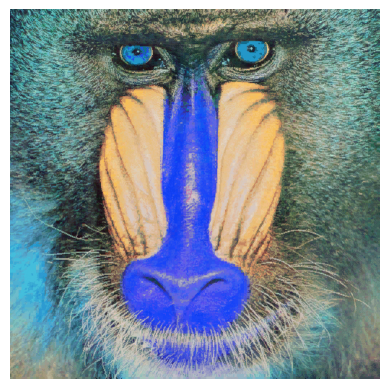

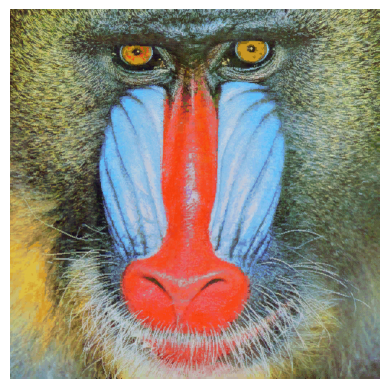

In [2]:
#Lee imagen de archivo
img = cv2.imread('mandril.jpg') 

#Si hay lectura correcta
if img is not None:
    #Muestra dimensiones
    print(img.shape)
    #Muestra la imagen original con matplotlib
    plt.figure()
    #Elimina etiquetas de los ejes que muestra matplotlib
    plt.axis("off")
    plt.imshow(img) 
    plt.show()

    #Recordar que OpenCV lee las imágenes almacenando en formato BGR, por lo que convertimos para visualizr de forma correcta a RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    #Muestra la imagen tras convertir a RGB
    #Eliminamos etiquetas de los ejes
    plt.figure()
    plt.axis("off")
    plt.imshow(img_rgb) 
    plt.show()
else: 
    print('Imagen no encontrada')

TAREA: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

3
[12, 20, 100]


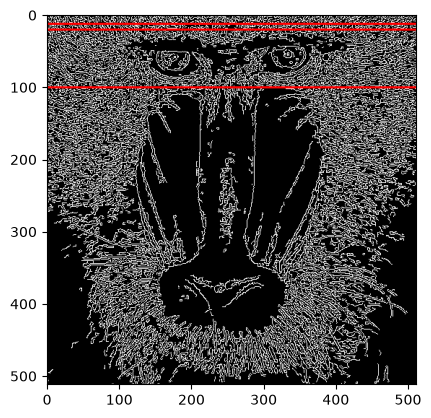

In [3]:
# Convierte imagen a blanco y negro
gris = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2GRAY)

# Detección de bordes con canny
canny = cv2.Canny(gris, 100, 200)

#Cuenta el número de píxeles blancos (255) por fila
#Suma los valores de los pixeles por fila
fila_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)  # devuelve una lista de los pixeles de cada fila ej: [0, 175, 56]

# Determina el valor maximo de pixeles blancos 
maxfil = max(fila_counts)

num_filas = 0
pos = []

for i in range(len(fila_counts)):
    if (fila_counts[i] >= maxfil*0.90):
        num_filas += 1
        pos.append(i)

print (num_filas)
print(pos)

canny_color = cv2.cvtColor(canny, cv2.COLOR_GRAY2RGB)

for y in pos:
    cv2.line(canny_color, (0, y), (gris.shape[1], y), (255,0,0), 2)

plt.imshow(canny_color) 
plt.show()


TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

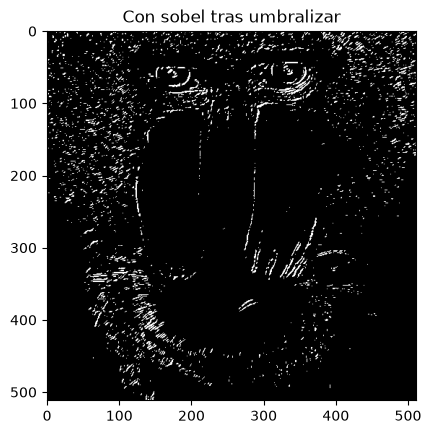

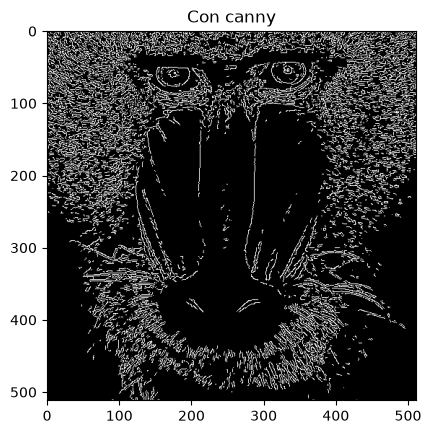

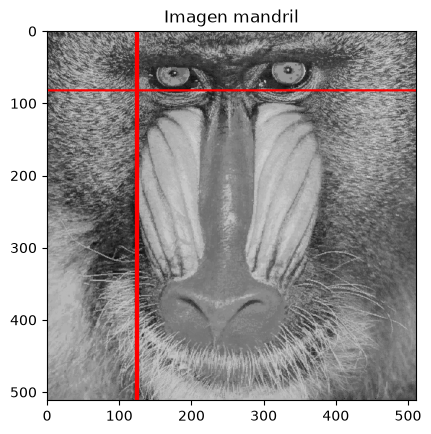

In [4]:
# Convierte a blanco y negro 
img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_color = cv2.cvtColor(img_gris, cv2.COLOR_GRAY2BGR)

# Suaviza la imagen original 
img_suavizada = cv2.GaussianBlur(img_gris, (3 ,3), 0)

# Calcula con sobel en ambas direcciones y los combina
sobelx = cv2.Sobel(img_suavizada, cv2.CV_64F, 1, 0)
sobely = cv2.Sobel(img_suavizada, cv2.CV_64F, 0, 1)
sobel = cv2.add(sobelx, sobely)

# Convierte a 8 bits
sobel8 = cv2.convertScaleAbs(sobel)

# Aplica umbralizado
# Se define umbral 
umbral = 190

_, imagenUmbralizada = cv2.threshold(sobel8, umbral, 255, cv2.THRESH_BINARY)

plt.title("Con sobel tras umbralizar")
plt.imshow(imagenUmbralizada, cmap='gray') 
plt.show()


# ----------------
# Detección de bordes con canny
canny = cv2.Canny(img_gris, 190, 255)
plt.title("Con canny")
plt.imshow(canny, cmap='gray') 
plt.show()
# ----------------


#Cuenta el número de píxeles blancos (255) y suma los valores de los pixeles por fila y columna
    # Al leer filas y columnas, openCV devuelve los datos empaquetados, por lo que se usa flatten para aplanarlos y que no de error
fila_counts = cv2.reduce(imagenUmbralizada, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1).flatten()
col_counts = cv2.reduce(imagenUmbralizada, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1).flatten()

# Determina el valor maximo de pixeles blancos 
maxfil = np.max(fila_counts) 
maxcol = np.max(col_counts)

num_filas = 0
num_col = 0

pos_filas = []
pos_col = []

for i in range(len(fila_counts)):
    if (fila_counts[i] >= maxfil*0.90):
        num_filas += 1
        pos_filas.append(i)

for j in range(len(col_counts)):
    if (col_counts[j] >= maxcol*0.90):
        num_col += 1
        pos_col.append(j)
    
# eje x     
for x in pos_filas:
    cv2.line(img_color, (0, x), (img_gris.shape[1], x), (255,0,0), 2)

# eje y 
for y in pos_col: 
    cv2.line(img_color, (y, 0), (y, img_gris.shape[0]), (255,0,0), 2)


plt.title("Imagen mandril")
plt.imshow(img_color, cmap='gray') 
plt.show()


Claro está que veremos resultados diferentes según el umbral que definamos en ambos:

Con sobel podemos observar que se generan bordes más gruesos, dando una sensación de más "ruido" a la imagen. Ocurre porque simplemente detecta cualquier cambio de luz que supere el umbral definido. Si hacemos la prueba suponiendo un umbral de 190 para ambos, vemos que con sobel apenas se marcan los bordes ya que si el pixel es mayor que el umbral, directamente lo pinta de blanco, sin tener en cuenta la fluctuación de la luz. 

Sin embargo, Canny aparte de ser más fácil de implementar porque todo lo que hemos hecho lo hace internamente dentro de la función, utiliza un doble umbral, los pixeles menores que el umbral minimo se descartan, y los mayores al umbral maximo se pintan de blanco. Si hay algun numero entre ambos umbrales, la función mira a sus píxeles vecinos.

Gracias a esto, con canny obtenemos lineas más finas y precisas en los bordes de la imagen al ajustar el umbral minimo y máximo. De forma que si aparecen muchos bordes, estamos utilizando umbrales muy bajos. Si por el contrario, aparecen menos bordes de los que debería tener la imagen, significa que los umbrales que estamos usando son muy altos. 


TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

In [5]:
pygame.mixer.init()

#Cargar los audios 
sonido_platillo = pygame.mixer.Sound("hi_hat.wav")
sonido_tom = pygame.mixer.Sound("tom.wav")
sonido_caja = pygame.mixer.Sound("snare_drum.wav")
sonido_triangulo = pygame.mixer.Sound("triangle.wav")

vid = cv2.VideoCapture(0)

disponible = 0

tocando_platillo = False
tocando_tom = False
tocando_caja = False
tocando_triangulo = False

color_resaltado = (0, 200, 150)

while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    if ret:
        frame = cv2.flip(frame, 1)

        height_third = frame.shape[0] // 3 * 2
        width_fourth = frame.shape[1] // 4

        hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

        rosa_bajo = np.array([140, 100, 100])
        rosa_alto = np.array([170, 255, 255])

        frameUmbralizado = cv2.inRange(hsv, rosa_bajo, rosa_alto)
        
        if disponible > 0:
            dif = cv2.absdiff(frameUmbralizado, pframe)   

           
            cuadr1 = dif[height_third:frame.shape[0], 0:width_fourth]
            cuadr2 = dif[height_third:frame.shape[0], width_fourth:width_fourth*2]
            cuadr3 = dif[height_third:frame.shape[0], width_fourth*2:width_fourth*3]
            cuadr4 = dif[height_third:frame.shape[0], width_fourth*3:frame.shape[1]]
     
            movimiento_cuadr1 = cv2.countNonZero(cuadr1)
            movimiento_cuadr2 = cv2.countNonZero(cuadr2)
            movimiento_cuadr3 = cv2.countNonZero(cuadr3)
            movimiento_cuadr4 = cv2.countNonZero(cuadr4)

            umbral_golpe = 100

            if (movimiento_cuadr1 > umbral_golpe):
                if not tocando_platillo:
                    sonido_platillo.play()
                    print("suena platillo")
                    tocando_platillo = True
                    overlay = frame.copy()
                    cv2.rectangle(overlay, (0, height_third), (width_fourth, frame.shape[0]), color_resaltado, -1)
                    frame = cv2.addWeighted(overlay, 0.8, frame, 0.2, 0)
            else:
                tocando_platillo = False

            if (movimiento_cuadr2 > umbral_golpe):
                if not tocando_tom:
                    sonido_tom.play()
                    print("suena tom base")
                    tocando_tom = True
                    overlay = frame.copy()
                    cv2.rectangle(overlay, (width_fourth, height_third), (width_fourth*2, frame.shape[0]), color_resaltado, -1)
                    frame = cv2.addWeighted(overlay, 0.8, frame, 0.2, 0)
            else:
                tocando_tom = False

            if (movimiento_cuadr3 > umbral_golpe):
                if not tocando_caja:
                    sonido_caja.play()
                    print("suena Caja")
                    tocando_caja = True
                    overlay = frame.copy()
                    cv2.rectangle(overlay, (width_fourth*2, height_third), (width_fourth*3, frame.shape[0]), color_resaltado, -1)
                    frame = cv2.addWeighted(overlay, 0.8, frame, 0.2, 0)
            else:
                tocando_caja = False

            if (movimiento_cuadr4 > umbral_golpe):
                if not tocando_bombo:
                    sonido_triangulo.play()
                    print("suena triangulo")
                    tocando_bombo = True
                    overlay = frame.copy()
                    cv2.rectangle(overlay, (width_fourth*3, height_third), (frame.shape[1], frame.shape[0]), color_resaltado, -1)
                    frame = cv2.addWeighted(overlay, 0.8, frame, 0.2, 0)
            else:
                tocando_bombo = False
            
               
        else:
            disponible = 1

        #Copia fotograma actual para la diferencia en el siguiente forograma
        pframe = frameUmbralizado.copy()
    

        cv2.line(frame, (width_fourth, frame.shape[0]),   (width_fourth, height_third),   (0, 255, 0), 5)
        cv2.line(frame, (width_fourth*2, frame.shape[0]), (width_fourth*2, height_third), (0, 255, 0), 5)
        cv2.line(frame, (width_fourth*3, frame.shape[0]), (width_fourth*3, height_third), (0, 255, 0), 5)
        cv2.line(frame, (0, height_third), (frame.shape[1], height_third), (0, 255, 0), 5)

        cv2.imshow("Mi bateria", frame)
    

    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()
cv2.waitKey(1)

suena Caja


-1